In [2]:
# ============================================================================
# PHASE 0: ENVIRONMENT SETUP & IMPORTS
# ============================================================================
%pip install -q tensorflow keras lightgbm xgboost catboost imbalanced-learn joblib shap scikit-learn matplotlib seaborn pandas numpy torch

import os
import sys
import time
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

# ML & DL imports
import torch
import tensorflow as tf
from tensorflow import keras
from keras import Model, Input, layers, callbacks, optimizers

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, roc_auc_score, average_precision_score,
                             precision_score, recall_score, f1_score, roc_curve, auc)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, StackingRegressor, StackingClassifier
from sklearn.linear_model import RidgeCV, LogisticRegression

import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostRegressor, CatBoostClassifier
import joblib
from packaging import version

# Display & style config
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
sns.set(style="whitegrid", font_scale=1.05)

RANDOM_STATE = 42
DATA_PATH = "multimodal_sports_injury_dataset.csv"
MODEL_DIR = "models"
RESULTS_DIR = "results"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# GPU check
print("GPU available (PyTorch):", torch.cuda.is_available())
print("Available GPUs (TensorFlow):", tf.config.list_physical_devices('GPU'))



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
GPU available (PyTorch): False
Available GPUs (TensorFlow): []



PHASE 1: DATA LOADING & EXPLORATORY DATA ANALYSIS
✅ Dataset loaded successfully with shape: (15420, 29)
   athlete_id  heart_rate  body_temperature  hydration_level  sleep_quality  \
0           1         NaN            37.049           76.481          5.466   
1           1      40.000            36.930           72.364          6.899   
2           1      76.175            36.335          100.000          9.574   
3           1     100.544            37.244           86.172          7.614   
4           1      78.001            36.511           83.196          5.632   

   recovery_score  stress_level  muscle_activity  joint_angles  gait_speed  \
0          77.900         0.376           10.000       126.480       2.654   
1          74.845         0.279          310.293       157.632       3.431   
2          83.538         0.334          158.659        81.766       0.800   
3          79.967         0.219          107.079       113.024       1.714   
4          56.946         0.48

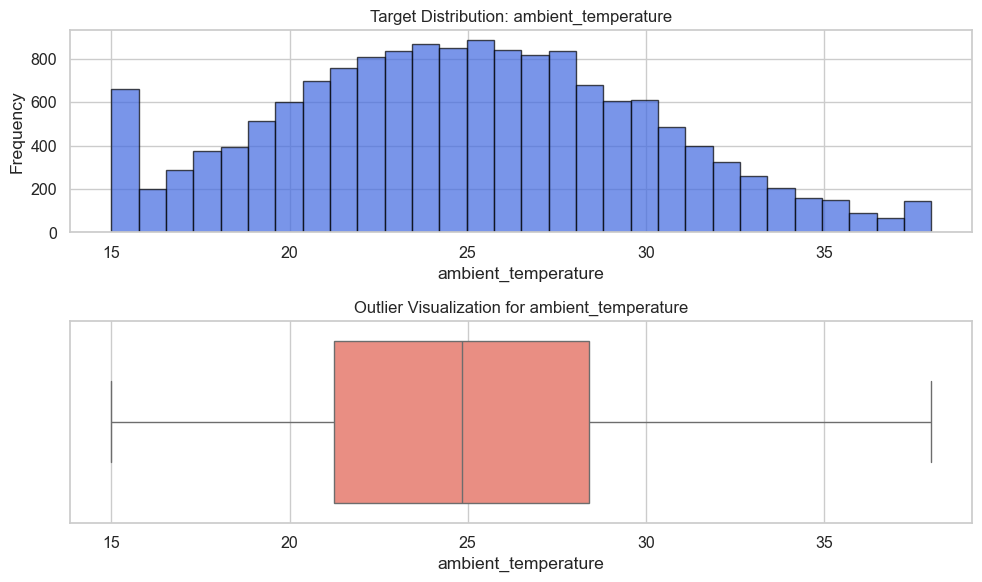

Number of outliers detected (IQR): 0


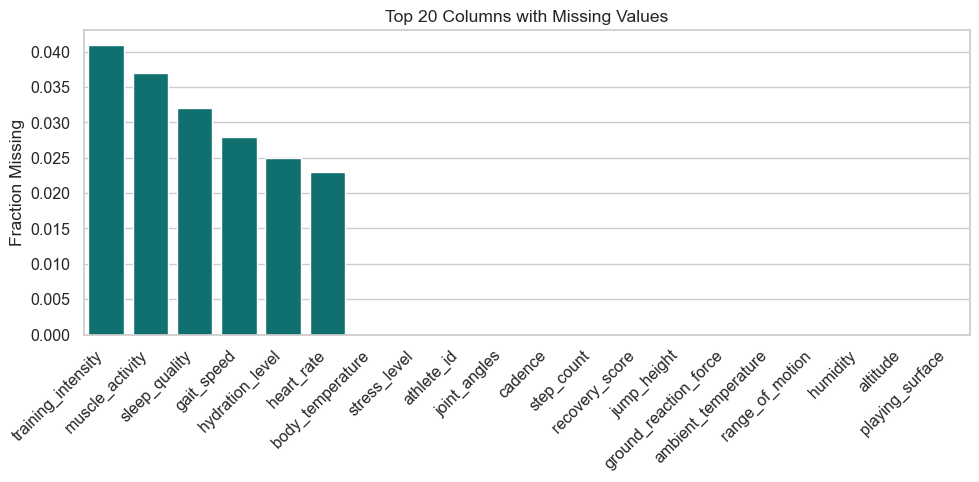


Features with missing values (>0):
                    missing_fraction
training_intensity             0.041
muscle_activity                0.037
sleep_quality                  0.032
gait_speed                     0.028
hydration_level                0.025
heart_rate                     0.023


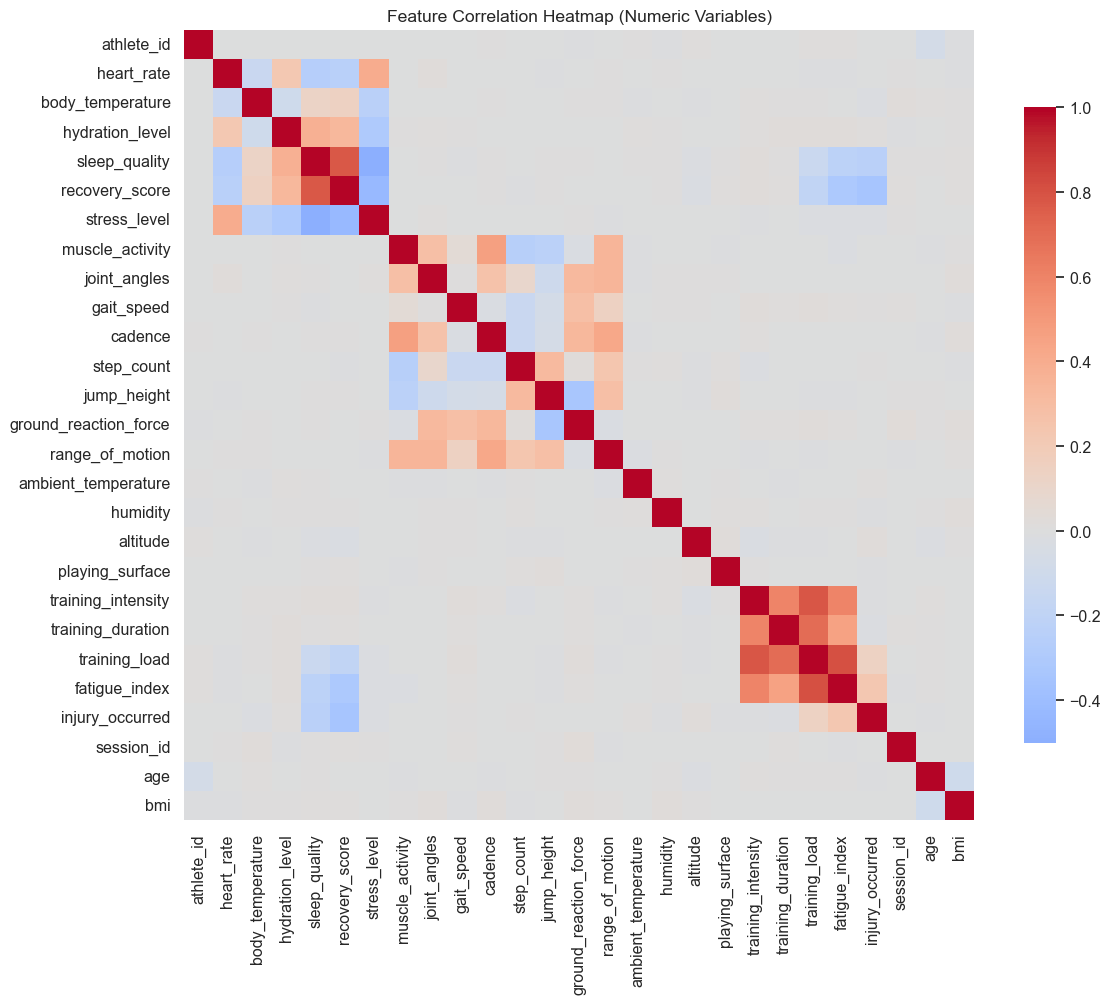


Top 20 features correlated with target:
ambient_temperature      1.000
hydration_level          0.012
injury_occurred          0.011
humidity                 0.010
athlete_id               0.008
step_count               0.005
sleep_quality            0.005
playing_surface          0.004
stress_level             0.003
altitude                 0.002
jump_height              0.002
age                      0.000
heart_rate              -0.000
training_load           -0.000
fatigue_index           -0.000
recovery_score          -0.000
gait_speed              -0.002
training_intensity      -0.002
session_id              -0.004
ground_reaction_force   -0.005
Name: ambient_temperature, dtype: float64


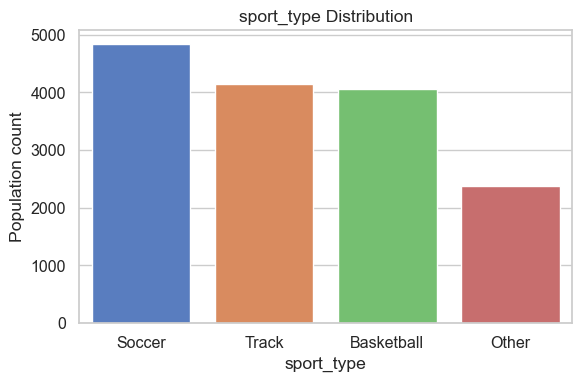


sport_type value counts (normalized):
sport_type
Soccer       0.314
Track        0.269
Basketball   0.263
Other        0.154
Name: proportion, dtype: float64


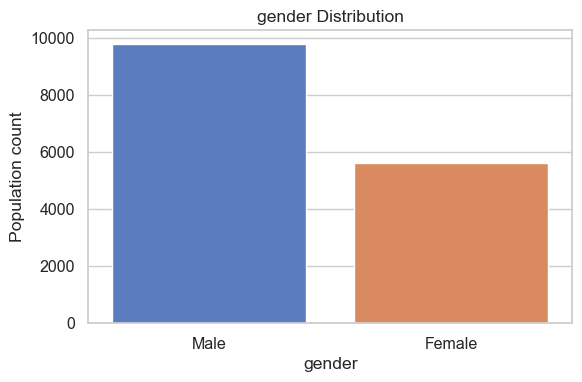


gender value counts (normalized):
gender
Male     0.635
Female   0.365
Name: proportion, dtype: float64


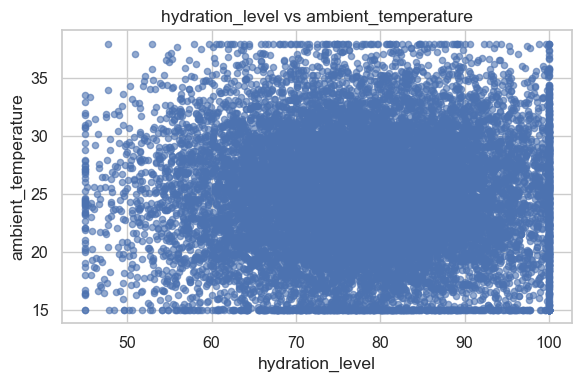

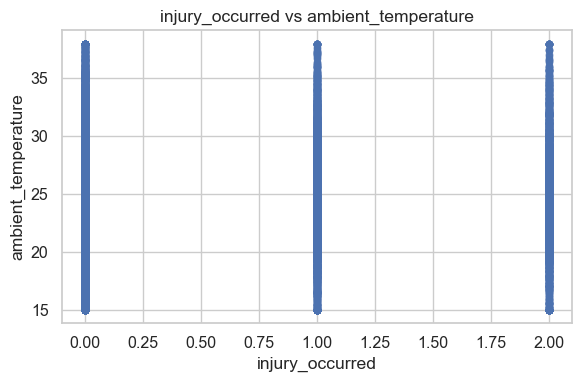

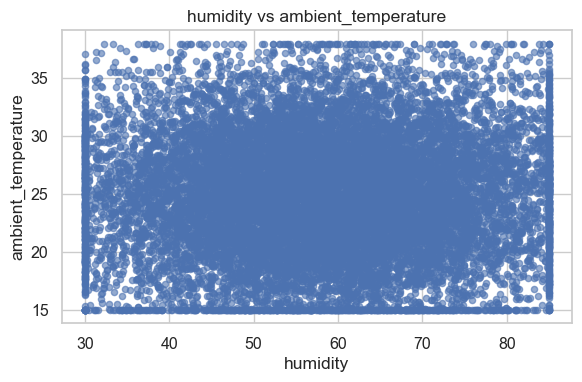

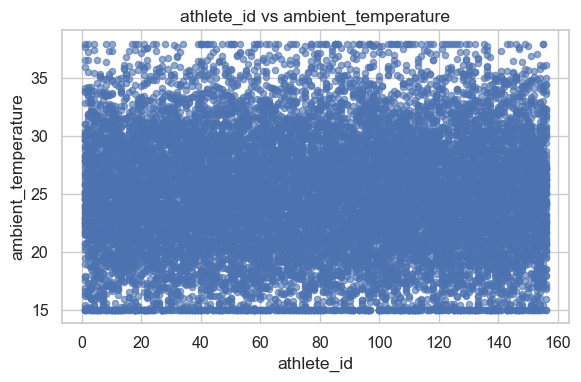

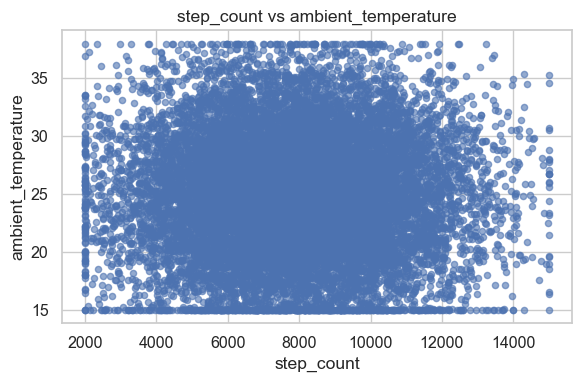

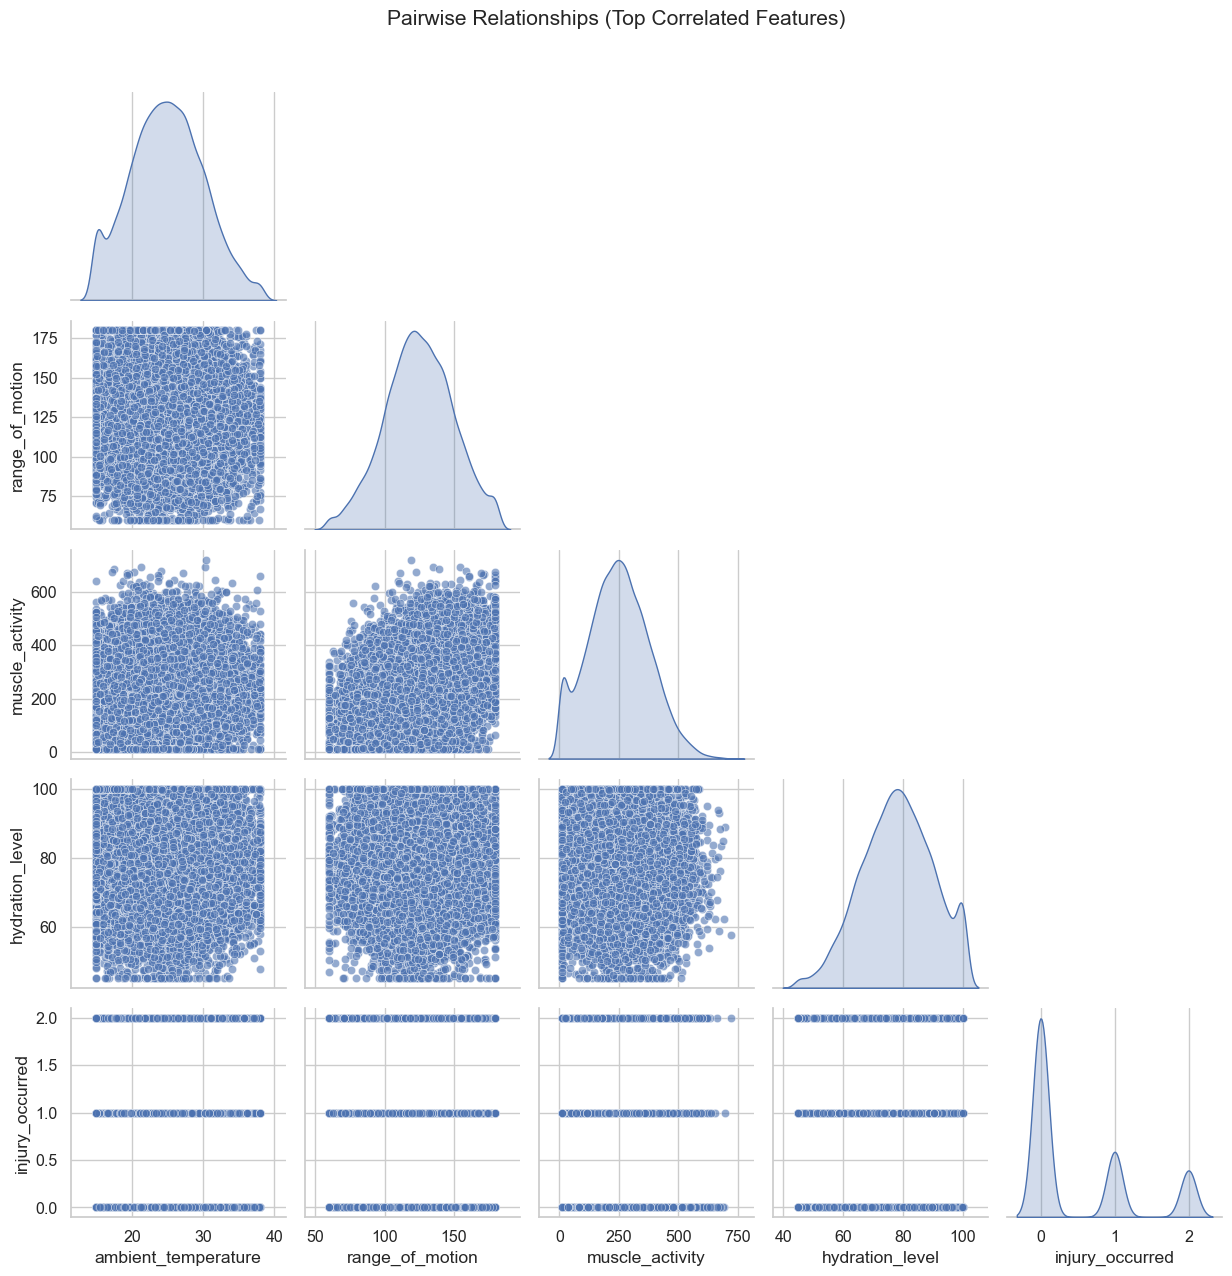

In [3]:
# ============================================================================
# PHASE 1: DATA LOADING & EDA
# ============================================================================
print("\n" + "="*80)
print("PHASE 1: DATA LOADING & EXPLORATORY DATA ANALYSIS")
print("="*80)

# Load dataset
try:
    df = pd.read_csv(DATA_PATH)
except FileNotFoundError:
    print("Warning: default DATA_PATH not found. Using local path if available.")
    df = pd.read_csv("multimodal_sports_injury_dataset.csv")

print(f"✅ Dataset loaded successfully with shape: {df.shape}")
print(df.head())
df.info()

# Identify column types & detect target
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nNumeric columns ({len(numeric_cols)}): {numeric_cols[:10]}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols[:10]}")

# Auto-detect continuous target (BMI-like values or max unique numeric col)
TARGET_COL = None
for col in numeric_cols:
    vals = df[col].dropna().unique()
    if any((np.isclose(vals, v)).any() for v in [18.5, 28.3]):
        TARGET_COL = col
        break

if TARGET_COL is None:
    TARGET_COL = max(numeric_cols, key=lambda c: df[c].nunique())

print(f"\nDetected continuous target variable: {TARGET_COL}")
print(df[[TARGET_COL]].describe())

# Target distribution & outlier detection
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

axes[0].hist(df[TARGET_COL].dropna(), bins=30, color='royalblue', alpha=0.7, edgecolor='black')
axes[0].set_title(f"Target Distribution: {TARGET_COL}", fontsize=12)
axes[0].set_xlabel(TARGET_COL)
axes[0].set_ylabel("Frequency")

sns.boxplot(x=df[TARGET_COL], color='salmon', ax=axes[1])
axes[1].set_title(f"Outlier Visualization for {TARGET_COL}", fontsize=12)
plt.tight_layout()
plt.show()

# Outlier detection (IQR)
Q1 = df[TARGET_COL].quantile(0.25)
Q3 = df[TARGET_COL].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[TARGET_COL] < (Q1 - 1.5 * IQR)) | (df[TARGET_COL] > (Q3 + 1.5 * IQR))).sum()
print(f"Number of outliers detected (IQR): {outliers}")

# Missing value analysis
missing_ratio = df.isnull().mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_ratio.index[:20], y=missing_ratio[:20], color='teal')
plt.title("Top 20 Columns with Missing Values")
plt.ylabel("Fraction Missing")
plt.xlabel("")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nFeatures with missing values (>0):")
print(missing_ratio[missing_ratio > 0].to_frame("missing_fraction").head(30))

# Numerical correlation analysis
num_df = df[numeric_cols].copy()
corr = num_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': 0.8})
plt.title("Feature Correlation Heatmap (Numeric Variables)")
plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = corr[TARGET_COL].sort_values(ascending=False)
print("\nTop 20 features correlated with target:")
print(target_corr.head(20))

# Categorical feature distributions
for col in categorical_cols[:5]:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, data=df, palette="muted", order=df[col].value_counts().index)
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=0)
    plt.ylabel("Population count")
    plt.tight_layout()
    plt.show()
    print(f"\n{col} value counts (normalized):")
    print(df[col].value_counts(normalize=True).head(10))

# Bivariate relationships (top correlated features)
top_corr_features = target_corr.head(6).index.drop(TARGET_COL, errors='ignore')
for feat in top_corr_features:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[feat], df[TARGET_COL], alpha=0.6, s=20)
    plt.xlabel(feat)
    plt.ylabel(TARGET_COL)
    plt.title(f"{feat} vs {TARGET_COL}")
    plt.tight_layout()
    plt.show()

# Pairplot for high-correlation features
high_corr_features = target_corr.abs().sort_values(ascending=False).head(5).index.tolist()
sns.pairplot(df[high_corr_features], corner=True, diag_kind="kde", plot_kws={"alpha": 0.6})
plt.suptitle("Pairwise Relationships (Top Correlated Features)", y=1.02)
plt.tight_layout()
plt.show()

In [4]:
# ============================================================================
# PHASE 2: DATA PREPROCESSING & FEATURE ENGINEERING
# ============================================================================
print("\n" + "="*80)
print("PHASE 2: DATA PREPROCESSING & TRAIN/TEST SPLIT")
print("="*80)

# Define feature lists
numeric_features = [c for c in numeric_cols if c != TARGET_COL]
cat_features = categorical_cols

# Build preprocessing pipelines
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Handle OneHotEncoder param differences across sklearn versions
ohe_kwargs = {"handle_unknown": "ignore"}
try:
    OneHotEncoder(**{"sparse_output": False})
    ohe_kwargs["sparse_output"] = False
except:
    ohe_kwargs["sparse"] = False

cat_pipeline_for_dl = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(**ohe_kwargs))
])

preprocessor_dl = ColumnTransformer([
    ("num", num_pipeline, numeric_features),
    ("cat", cat_pipeline_for_dl, cat_features)
], remainder="drop")

# Build preprocessed arrays
X_dl = preprocessor_dl.fit_transform(df.drop(columns=[TARGET_COL]))
y = df[TARGET_COL].values.ravel()

# Build feature names
feature_names_dl = []
feature_names_dl.extend(numeric_features)
if len(cat_features) > 0:
    ohe = preprocessor_dl.named_transformers_["cat"]["onehot"]
    try:
        ohe_cols = ohe.get_feature_names_out(cat_features).tolist()
    except:
        n_ohe = X_dl.shape[1] - len(numeric_features)
        ohe_cols = [f"ohe_{i}" for i in range(n_ohe)]
    feature_names_dl.extend(ohe_cols)

print(f"Preprocessed X_dl shape: {X_dl.shape}")

# Train/test split
X_train_dl, X_test_dl, y_train, y_test, idx_train, idx_test = train_test_split(
    X_dl, y, df.index.values, test_size=0.2, random_state=RANDOM_STATE, shuffle=True
)

print(f"Train shapes: X={X_train_dl.shape}, y={y_train.shape}")
print(f"Test shapes:  X={X_test_dl.shape}, y={y_test.shape}")

# For tree models: prepare DataFrame inputs
X_tree_df = df.drop(columns=[TARGET_COL]).reset_index(drop=True)
X_tree_train_df = X_tree_df.loc[idx_train].reset_index(drop=True)
X_tree_test_df = X_tree_df.loc[idx_test].reset_index(drop=True)



PHASE 2: DATA PREPROCESSING & TRAIN/TEST SPLIT
Preprocessed X_dl shape: (15420, 32)
Train shapes: X=(12336, 32), y=(12336,)
Test shapes:  X=(3084, 32), y=(3084,)


In [5]:
# ============================================================================
# PHASE 3: UTILITY FUNCTIONS & METRICS
# ============================================================================
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate_regression(y_true, y_pred):
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(rmse(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred))
    }

def cross_val_score_dict(model, X, y, cv=5):
    """KFold cross-validation returning average metrics"""
    kf = KFold(n_splits=cv, shuffle=True, random_state=RANDOM_STATE)
    metrics = defaultdict(list)
    for tr_idx, val_idx in kf.split(X):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        model.fit(X_tr, y_tr)
        pred = model.predict(X_val)
        m = evaluate_regression(y_val, pred)
        for k, v in m.items():
            metrics[k].append(v)
    return {k: np.mean(v) for k, v in metrics.items()}

def compute_classification_metrics(y_true, y_prob, y_pred=None):
    """Compute classification metrics"""
    if y_pred is None:
        y_pred = (y_prob >= 0.5).astype(int)
    try:
        roc = roc_auc_score(y_true, y_prob)
    except:
        roc = np.nan
    try:
        ap = average_precision_score(y_true, y_prob)
    except:
        ap = np.nan
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "roc_auc": float(roc),
        "average_precision": float(ap),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0))
    }

def train_lgb_with_earlystopping(X_tr, y_tr, X_val, y_val, params=None, early_stopping_rounds=50):
    """Train LightGBM with version-safe early stopping"""
    params = params or {}
    model = lgb.LGBMRegressor(**params)
    evals_result = {}
    try:
        if version.parse(lgb.__version__) >= version.parse("4.0.0"):
            from lightgbm import early_stopping, record_evaluation, log_evaluation
            rec = {}
            model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                      callbacks=[early_stopping(stopping_rounds=early_stopping_rounds),
                                 record_evaluation(rec), log_evaluation(period=0)])
            evals_result = rec
        else:
            model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                      early_stopping_rounds=early_stopping_rounds, verbose=0)
            try:
                evals_result = model.booster_.evals_result()
            except:
                evals_result = {}
    except Exception as e:
        print(f"LightGBM early-stopping fallback: {e}")
        model.fit(X_tr, y_tr)
    return model, evals_result


PHASE 4: REGRESSION MODELS TRAINING

>>> Training LightGBM Regressor...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001250 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5551
[LightGBM] [Info] Number of data points in the train set: 12336, number of used features: 32
[LightGBM] [Info] Start training from score 24.884579
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[5]	valid_0's l2: 25.7626
 LightGBM: MAE=4.0902, RMSE=5.0757, R2=0.0006

>>> Training XGBoost Regressor...
 XGBoost: MAE=4.1900, RMSE=5.2146, R2=-0.0548

>>> Training CatBoost Regressor...
 CatBoost: MAE=4.0922, RMSE=5.0781, R2=-0.0003

>>> Training RandomForest Regressor...
 RandomForest: MAE=4.1122, RMSE=5.0959, R2=-0.0073

>>> Training Stacking Regressor (LGB + XGB + RF)...
 Stacking: MAE=4.0941, RMSE=5.0810, R2=-0.0015

REGRESSION RESULTS SUMMARY
                model   MAE  RMSE

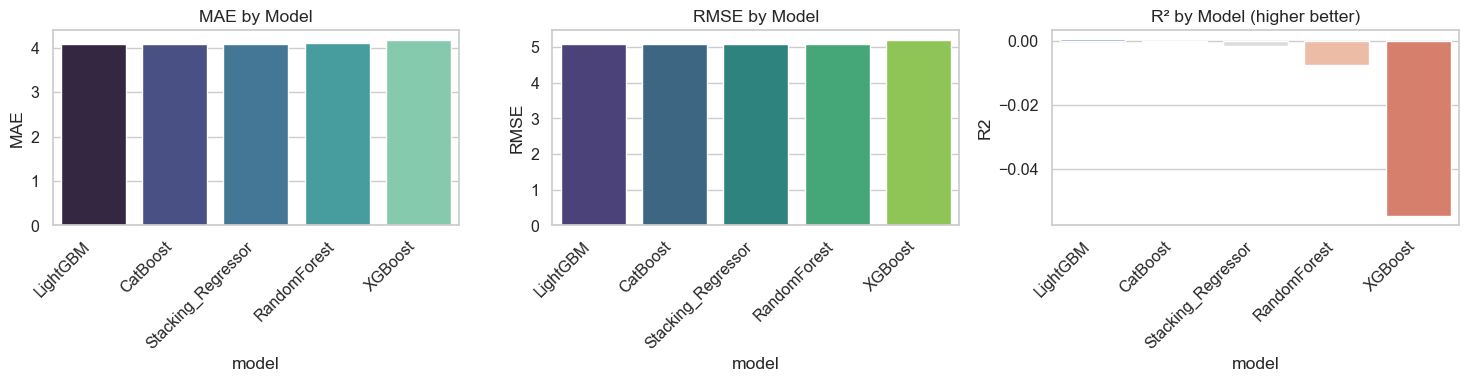

In [6]:
# ============================================================================
# PHASE 4: REGRESSION MODELS (Tree-based + Stacking)
# ============================================================================
print("\n" + "="*80)
print("PHASE 4: REGRESSION MODELS TRAINING")
print("="*80)

regression_results = []
regression_models = {}

# LightGBM
print("\n>>> Training LightGBM Regressor...")
start = time.time()
lgb_model = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, random_state=RANDOM_STATE)
try:
    lgb_model.fit(X_train_dl, y_train, eval_set=[(X_test_dl, y_test)],
                  callbacks=[lgb.early_stopping(50)] if version.parse(lgb.__version__) >= version.parse("4.0.0") else [])
except:
    lgb_model.fit(X_train_dl, y_train)
elapsed = time.time() - start
pred = lgb_model.predict(X_test_dl)
metrics = evaluate_regression(y_test, pred)
metrics.update({"model": "LightGBM", "time_s": elapsed})
regression_results.append(metrics)
regression_models["LightGBM"] = lgb_model
print(f" LightGBM: MAE={metrics['MAE']:.4f}, RMSE={metrics['RMSE']:.4f}, R2={metrics['R2']:.4f}")

# XGBoost
print("\n>>> Training XGBoost Regressor...")
start = time.time()
xgb_model = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, verbosity=0, random_state=RANDOM_STATE)
try:
    xgb_model.fit(X_train_dl, y_train, eval_set=[(X_test_dl, y_test)], early_stopping_rounds=50, verbose=False)
except:
    xgb_model.fit(X_train_dl, y_train, verbose=False)
elapsed = time.time() - start
pred = xgb_model.predict(X_test_dl)
metrics = evaluate_regression(y_test, pred)
metrics.update({"model": "XGBoost", "time_s": elapsed})
regression_results.append(metrics)
regression_models["XGBoost"] = xgb_model
print(f" XGBoost: MAE={metrics['MAE']:.4f}, RMSE={metrics['RMSE']:.4f}, R2={metrics['R2']:.4f}")

# CatBoost
print("\n>>> Training CatBoost Regressor...")
start = time.time()
try:
    catboost_model = CatBoostRegressor(iterations=1000, learning_rate=0.05, random_seed=RANDOM_STATE, verbose=0)
    catboost_model.fit(X_tree_train_df, y_train, cat_features=cat_features,
                       eval_set=(X_tree_test_df, y_test), use_best_model=True)
    elapsed = time.time() - start
    pred = catboost_model.predict(X_tree_test_df)
    metrics = evaluate_regression(y_test, pred)
    metrics.update({"model": "CatBoost", "time_s": elapsed})
    regression_results.append(metrics)
    regression_models["CatBoost"] = catboost_model
    print(f" CatBoost: MAE={metrics['MAE']:.4f}, RMSE={metrics['RMSE']:.4f}, R2={metrics['R2']:.4f}")
except Exception as e:
    print(f" CatBoost failed: {e}")

# RandomForest
print("\n>>> Training RandomForest Regressor...")
start = time.time()
rf = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_dl, y_train)
elapsed = time.time() - start
pred = rf.predict(X_test_dl)
metrics = evaluate_regression(y_test, pred)
metrics.update({"model": "RandomForest", "time_s": elapsed})
regression_results.append(metrics)
regression_models["RandomForest"] = rf
print(f" RandomForest: MAE={metrics['MAE']:.4f}, RMSE={metrics['RMSE']:.4f}, R2={metrics['R2']:.4f}")

# Stacking Regressor
print("\n>>> Training Stacking Regressor (LGB + XGB + RF)...")
start = time.time()
estimators = [
    ("lgb", lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE)),
    ("xgb", xgb.XGBRegressor(n_estimators=300, learning_rate=0.05, verbosity=0, random_state=RANDOM_STATE)),
    ("rf", RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))
]
stack = StackingRegressor(estimators=estimators, final_estimator=RidgeCV(), n_jobs=-1, passthrough=False)
try:
    stack.fit(X_train_dl, y_train)
    elapsed = time.time() - start
    pred = stack.predict(X_test_dl)
    metrics = evaluate_regression(y_test, pred)
    metrics.update({"model": "Stacking_Regressor", "time_s": elapsed})
    regression_results.append(metrics)
    regression_models["Stacking_Regressor"] = stack
    print(f" Stacking: MAE={metrics['MAE']:.4f}, RMSE={metrics['RMSE']:.4f}, R2={metrics['R2']:.4f}")
except Exception as e:
    print(f" Stacking failed: {e}")

# Save regression results
reg_df = pd.DataFrame(regression_results).sort_values("MAE").reset_index(drop=True)
reg_df.to_csv(f"{RESULTS_DIR}/regression_model_results.csv", index=False)
print("\n" + "="*80)
print("REGRESSION RESULTS SUMMARY")
print("="*80)
print(reg_df[["model", "MAE", "RMSE", "R2", "time_s"]])

# Plot regression results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(x="model", y="MAE", data=reg_df, palette="mako", ax=axes[0])
axes[0].set_title("MAE by Model")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
sns.barplot(x="model", y="RMSE", data=reg_df, palette="viridis", ax=axes[1])
axes[1].set_title("RMSE by Model")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
sns.barplot(x="model", y="R2", data=reg_df, palette="coolwarm", ax=axes[2])
axes[2].set_title("R² by Model (higher better)")

axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()


PHASE 5: AUTOENCODER LATENT EMBEDDINGS

Building autoencoder (input_dim=32, latent_dim=8)...
Epoch 1/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.7443 - val_loss: 0.5608
Epoch 2/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5082 - val_loss: 0.4724
Epoch 3/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4671 - val_loss: 0.4538
Epoch 4/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4554 - val_loss: 0.4483
Epoch 5/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4498 - val_loss: 0.4433
Epoch 6/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4456 - val_loss: 0.4400
Epoch 7/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4426 - val_loss: 0.4370
Epoch 8/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4395 - val_loss: 0.4329
Epoch 9/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4367 - val_loss: 0.4309
Epoch 10/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4346 - val_loss: 0.4295
Epoch 11/100
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - l

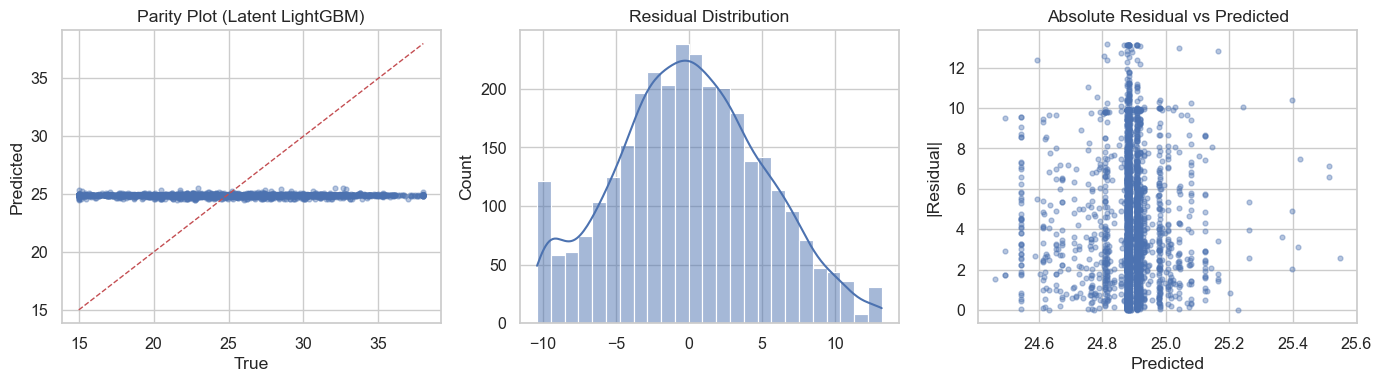

In [7]:
# ============================================================================
# PHASE 5: AUTOENCODER + LATENT EMBEDDINGS
# ============================================================================
print("\n" + "="*80)
print("PHASE 5: AUTOENCODER LATENT EMBEDDINGS")
print("="*80)

LATENT_TRAIN_FILE = f"{MODEL_DIR}/X_train_latent.npy"
LATENT_TEST_FILE = f"{MODEL_DIR}/X_test_latent.npy"

# Build & train compact autoencoder
input_dim = X_train_dl.shape[1]
latent_dim = min(32, max(8, input_dim // 4))

print(f"\nBuilding autoencoder (input_dim={input_dim}, latent_dim={latent_dim})...")

inp = Input(shape=(input_dim,), name="ae_input")
x = layers.Dense(128, activation="relu")(inp) if input_dim >= 128 else layers.Dense(64, activation="relu")(inp)
x = layers.Dense(64, activation="relu")(x)
bottleneck = layers.Dense(latent_dim, activation="relu", name="bottleneck")(x)
x = layers.Dense(64, activation="relu")(bottleneck)
x = layers.Dense(128, activation="relu")(x) if input_dim >= 128 else x
out = layers.Dense(input_dim, activation="linear")(x)

autoencoder = tf.keras.Model(inputs=inp, outputs=out, name="autoencoder")
autoencoder.compile(optimizer=optimizers.Adam(1e-3), loss="mse")

es = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=0)
history = autoencoder.fit(X_train_dl, X_train_dl, validation_split=0.1, epochs=100,
                          batch_size=128, callbacks=[es], verbose=1)

# Build encoder from trained autoencoder
encoder = Model(inputs=autoencoder.input, outputs=autoencoder.get_layer("bottleneck").output)

# Compute latent embeddings
X_train_latent = encoder.predict(np.asarray(X_train_dl), verbose=0)
X_test_latent = encoder.predict(np.asarray(X_test_dl), verbose=0)

np.save(LATENT_TRAIN_FILE, X_train_latent)
np.save(LATENT_TEST_FILE, X_test_latent)

# Save models
autoencoder.save(f"{MODEL_DIR}/autoencoder_model.keras")
encoder.save(f"{MODEL_DIR}/encoder_model.keras")

print(f"Latent embeddings: train={X_train_latent.shape}, test={X_test_latent.shape}")
print(f"Saved autoencoder and encoder models")

# Train LightGBM on latent embeddings with CV
print("\n>>> Training LightGBM on latent embeddings with 5-fold CV...")

CV_FOLDS = 5
kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
base_params = {"n_estimators": 1000, "learning_rate": 0.05, "random_state": RANDOM_STATE, "n_jobs": -1}

cv_metrics = {"MAE": [], "RMSE": [], "R2": []}
for fold, (tr_idx, val_idx) in enumerate(kf.split(X_train_latent)):
    X_tr, X_val = X_train_latent[tr_idx], X_train_latent[val_idx]
    y_tr, y_val = y_train[tr_idx], y_train[val_idx]
    st = time.time()
    model_fold, _ = train_lgb_with_earlystopping(X_tr, y_tr, X_val, y_val, params=base_params)
    elapsed = time.time() - st
    y_val_pred = model_fold.predict(X_val)
    m = evaluate_regression(y_val, y_val_pred)
    cv_metrics["MAE"].append(m["MAE"])
    cv_metrics["RMSE"].append(m["RMSE"])
    cv_metrics["R2"].append(m["R2"])
    print(f" Fold {fold+1}: MAE={m['MAE']:.4f}, RMSE={m['RMSE']:.4f}, R2={m['R2']:.4f} ({elapsed:.1f}s)")

cv_summary = {
    "MAE_mean": np.mean(cv_metrics["MAE"]), "MAE_std": np.std(cv_metrics["MAE"]),
    "RMSE_mean": np.mean(cv_metrics["RMSE"]), "RMSE_std": np.std(cv_metrics["RMSE"]),
    "R2_mean": np.mean(cv_metrics["R2"]), "R2_std": np.std(cv_metrics["R2"])
}
print("\nCross-validation summary (latent embeddings):")
print(pd.Series(cv_summary).to_frame("value"))

# Final LightGBM on latent
print("\n>>> Training final LightGBM on full training set (latent)...")
st = time.time()
final_lgb_latent, final_eval_hist = train_lgb_with_earlystopping(
    X_train_latent, y_train, X_test_latent, y_test, params=base_params
)
t_final = time.time() - st

y_test_pred_latent = final_lgb_latent.predict(X_test_latent)
metrics_latent = evaluate_regression(y_test, y_test_pred_latent)
metrics_latent.update({"model": "Autoencoder+LightGBM", "time_s": t_final})
regression_results.append(metrics_latent)
regression_models["Autoencoder+LightGBM"] = (autoencoder, encoder, final_lgb_latent)

print(f" Final: MAE={metrics_latent['MAE']:.4f}, RMSE={metrics_latent['RMSE']:.4f}, R2={metrics_latent['R2']:.4f}")

# Diagnostic plots for latent model
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(y_test, y_test_pred_latent, alpha=0.4, s=12)
mn, mx = min(y_test.min(), y_test_pred_latent.min()), max(y_test.max(), y_test_pred_latent.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1)
axes[0].set_xlabel("True")
axes[0].set_ylabel("Predicted")
axes[0].set_title("Parity Plot (Latent LightGBM)")

res = y_test - y_test_pred_latent
sns.histplot(res, kde=True, ax=axes[1])
axes[1].set_title("Residual Distribution")

axes[2].scatter(y_test_pred_latent, np.abs(res), alpha=0.4, s=12)
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("|Residual|")
axes[2].set_title("Absolute Residual vs Predicted")

plt.tight_layout()
plt.show()


PHASE 6: WIDE & DEEP NEURAL NETWORK
Selected top 8 features for wide branch

Training Wide & Deep model...
Epoch 1/200
71/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 355.8638 - mae: 16.1887

87/87 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 145.0677 - mae: 8.9359 - val_loss: 34.3381 - val_mae: 4.7119
Epoch 2/200
74/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 35.1052 - mae: 4.7776

87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 34.2397 - mae: 4.7184 - val_loss: 32.0743 - val_mae: 4.5665
Epoch 3/200
65/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 32.5034 - mae: 4.6039

87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 32.1742 - mae: 4.5675 - val_loss: 30.5237 - val_mae: 4.4626
Epoch 4/200
68/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 30.8052 - mae: 4.4683

87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 30.9059 - mae: 4.4787 - val_loss: 29.5180 - val_mae: 4.3928
Epoch 5/200
80/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 29.3652 - mae: 4.3748

...

87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 28.6097 - mae: 4.3261 - val_loss: 28.0514 - val_mae: 4.2897
Epoch 8/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 28.2892 - mae: 4.2900 - val_loss: 28.4163 - val_mae: 4.2989
Epoch 9/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 28.0786 - mae: 4.2900 - val_loss: 28.1576 - val_mae: 4.2802
Epoch 10/200
77/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 27.8662 - mae: 4.2799

87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 27.6069 - mae: 4.2613 - val_loss: 27.9071 - val_mae: 4.2688
Epoch 11/200
77/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 26.5824 - mae: 4.1647

87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 27.5499 - mae: 4.2425 - val_loss: 27.6782 - val_mae: 4.2571
Epoch 12/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 27.2455 - mae: 4.2300 - val_loss: 27.7998 - val_mae: 4.2689
Epoch 13/200
71/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 26.6297 - mae: 4.1777

87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 27.0629 - mae: 4.2147 - val_loss: 27.5497 - val_mae: 4.2407
Epoch 14/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 26.8851 - mae: 4.2106 - val_loss: 27.8185 - val_mae: 4.2591
Epoch 15/200
77/87 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 26.6772 - mae: 4.1843

87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 26.6583 - mae: 4.1801 - val_loss: 27.3975 - val_mae: 4.2282
Epoch 16/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 26.7924 - mae: 4.1859 - val_loss: 31.6815 - val_mae: 4.5062
Epoch 17/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 26.3280 - mae: 4.1698 - val_loss: 27.6681 - val_mae: 4.2510
Epoch 18/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 26.2547 - mae: 4.1523 - val_loss: 27.9434 - val_mae: 4.2828
Epoch 19/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 26.0890 - mae: 4.1373 - val_loss: 28.0418 - val_mae: 4.2697
Epoch 20/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 26.2494 - mae: 4.1495 - val_loss: 28.0170 - val_mae: 4.2712
Epoch 21/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 26.0388 - mae: 4.1398 - val_loss: 27.5941 - val_mae: 4.2358
Epoch 22/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 25.6800 - mae: 4.1048 - val_loss: 28.5233 - val_mae: 4.2983
Epoch 23/200
87/87 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step -

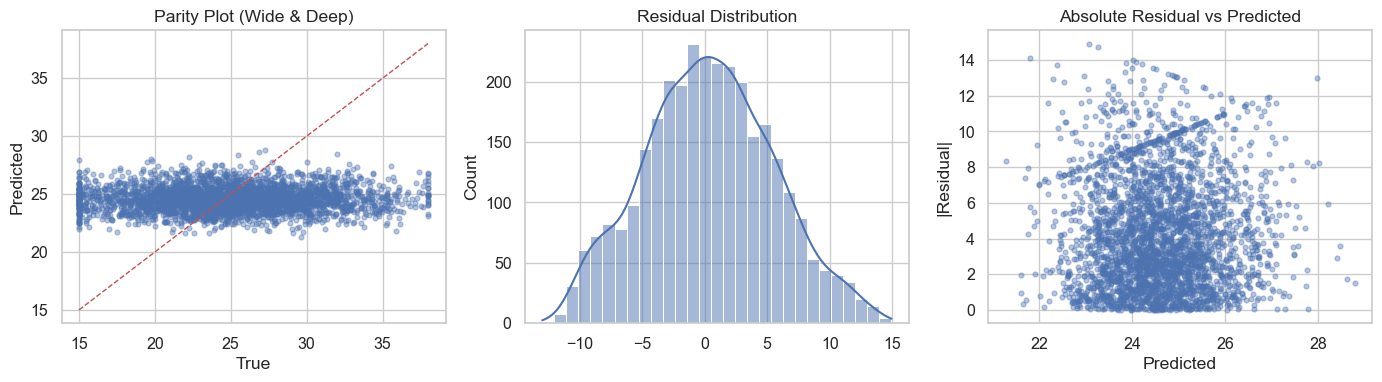

In [8]:
# ============================================================================
# PHASE 6: WIDE & DEEP LEARNING MODEL
# ============================================================================
print("\n" + "="*80)
print("PHASE 6: WIDE & DEEP NEURAL NETWORK")
print("="*80)

# Select wide features (top k by abs correlation)
k_wide = min(8, X_train_dl.shape[1])
try:
    corrs = []
    for i in range(X_train_dl.shape[1]):
        xi = X_train_dl[:, i]
        if np.all(np.isfinite(xi)) and np.std(xi) > 0:
            corr = np.corrcoef(xi, y_train)[0, 1]
        else:
            corr = 0.0
        corrs.append(abs(corr))
    top_idx = list(np.argsort(corrs)[-k_wide:][::-1])
except:
    top_idx = list(range(k_wide))

print(f"Selected top {k_wide} features for wide branch")

input_dim = X_train_dl.shape[1]

# Wide input
wide_input = Input(shape=(k_wide,), name="wide_input")
wide_dense = layers.Dense(max(16, k_wide*4), activation="relu")(wide_input)
wide_dense = layers.Dropout(0.1)(wide_dense)
wide_out = layers.Dense(32, activation="relu")(wide_dense)

# Deep input
deep_input = Input(shape=(input_dim,), name="deep_input")
x = layers.Dense(256, activation="relu")(deep_input)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dense(64, activation="relu")(x)
deep_out = layers.Dense(64, activation="relu")(x)

# Combine
concat = layers.Concatenate()([wide_out, deep_out])
x = layers.Dense(64, activation="relu")(concat)
x = layers.Dense(16, activation="relu")(x)
out = layers.Dense(1, activation="linear")(x)

wide_deep = Model(inputs=[wide_input, deep_input], outputs=out, name="WideDeep")
wide_deep.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss="mse", metrics=["mae"])

X_wide_train = X_train_dl[:, top_idx]
X_wide_test = X_test_dl[:, top_idx]

# Train
print("\nTraining Wide & Deep model...")
ckpt_path = f"{MODEL_DIR}/wide_deep_best.h5"
es = callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True, verbose=0)
mc = callbacks.ModelCheckpoint(ckpt_path, monitor="val_loss", save_best_only=True, verbose=0)

history_wd = wide_deep.fit(
    [X_wide_train, X_train_dl], y_train,
    validation_split=0.1,
    epochs=200,
    batch_size=128,
    callbacks=[es, mc],
    verbose=1
)

# Reload best model
try:
    wide_deep = tf.keras.models.load_model(ckpt_path)
except:
    pass

# Evaluate
y_pred_wd = wide_deep.predict([X_wide_test, X_test_dl], verbose=0).ravel()
metrics_wd = evaluate_regression(y_test, y_pred_wd)
metrics_wd.update({"model": "WideDeep_Keras", "time_s": 0})
regression_results.append(metrics_wd)
regression_models["WideDeep_Keras"] = wide_deep

print(f"Wide & Deep: MAE={metrics_wd['MAE']:.4f}, RMSE={metrics_wd['RMSE']:.4f}, R2={metrics_wd['R2']:.4f}")

print(f"Wide & Deep: MAE={metrics_wd['MAE']:.4f}, RMSE={metrics_wd['RMSE']:.4f}, R2={metrics_wd['R2']:.4f}")

# Diagnostic plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(y_test, y_pred_wd, alpha=0.4, s=12)
mn, mx = min(y_test.min(), y_pred_wd.min()), max(y_test.max(), y_pred_wd.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1)
axes[0].set_xlabel("True")
axes[0].set_ylabel("Predicted")
axes[0].set_title("Parity Plot (Wide & Deep)")

res = y_test - y_pred_wd
sns.histplot(res, kde=True, ax=axes[1])
axes[1].set_title("Residual Distribution")

axes[2].scatter(y_pred_wd, np.abs(res), alpha=0.4, s=12)
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("|Residual|")
axes[2].set_title("Absolute Residual vs Predicted")

plt.tight_layout()
plt.show()


PHASE 7: BINARY CLASSIFICATION (Top 15% High-Risk)
Threshold (top 15%): 30.280523
Positive class (high-risk): 15.0%

>>> Training LightGBMClassifier...
[LightGBM] [Info] Number of positive: 1850, number of negative: 10486
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001358 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5551
[LightGBM] [Info] Number of data points in the train set: 12336, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.149968 -> initscore=-1.734855
[LightGBM] [Info] Start training from score -1.734855
 LGBM: ROC-AUC=0.4900, F1=0.0000

>>> Training XGBClassifier...
 XGB: ROC-AUC=0.4965, F1=0.0123

>>> Training CatBoostClassifier...
 CatBoost: ROC-AUC=0.5086, F1=0.0000

>>> Training RandomForestClassifier...
 RF: ROC-AUC=0.4793, F1=0.0000

>>> Training StackingClassifier...
 Stacking: ROC-AUC=0.4790, F1=0.0000

CLASSIFICATION RESULTS SUMMARY (sorted b

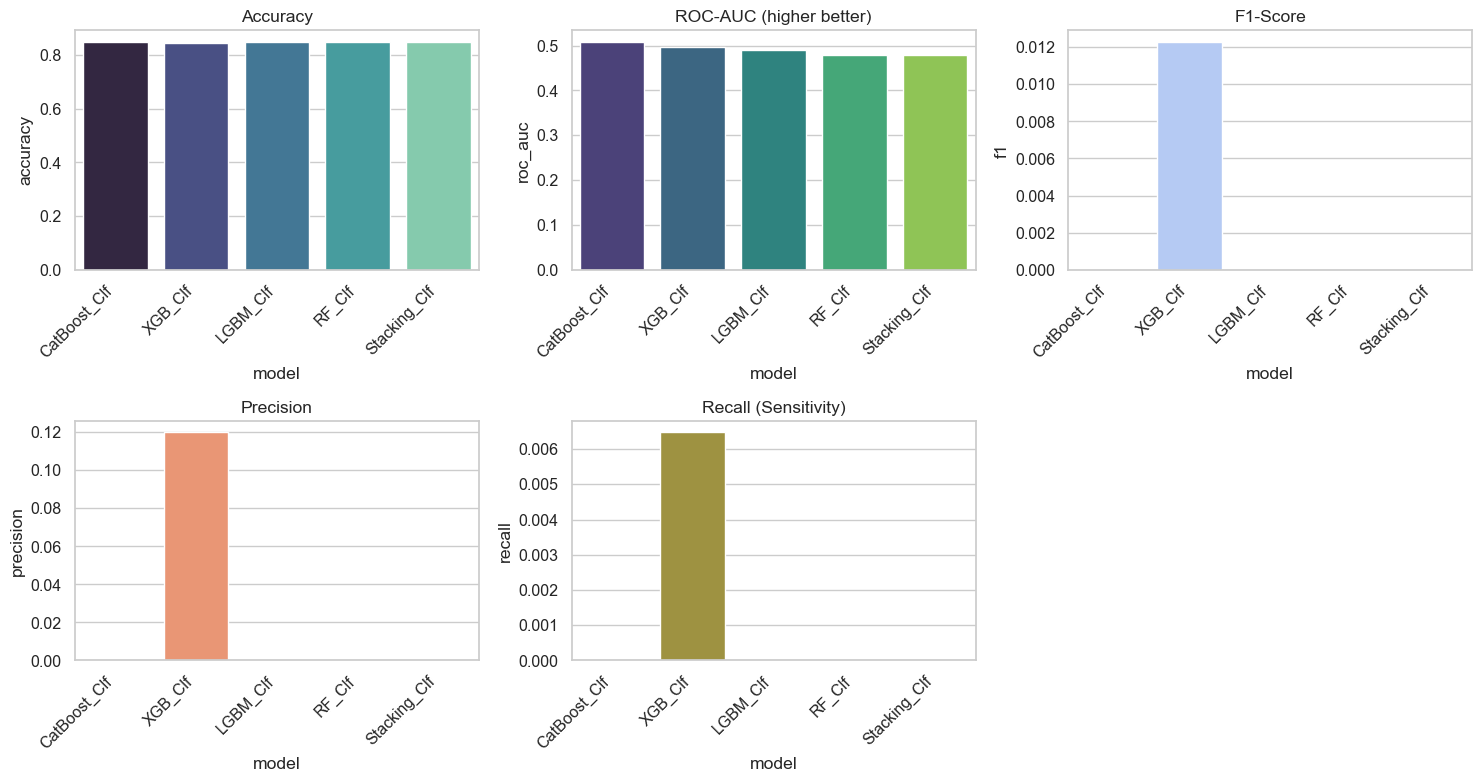

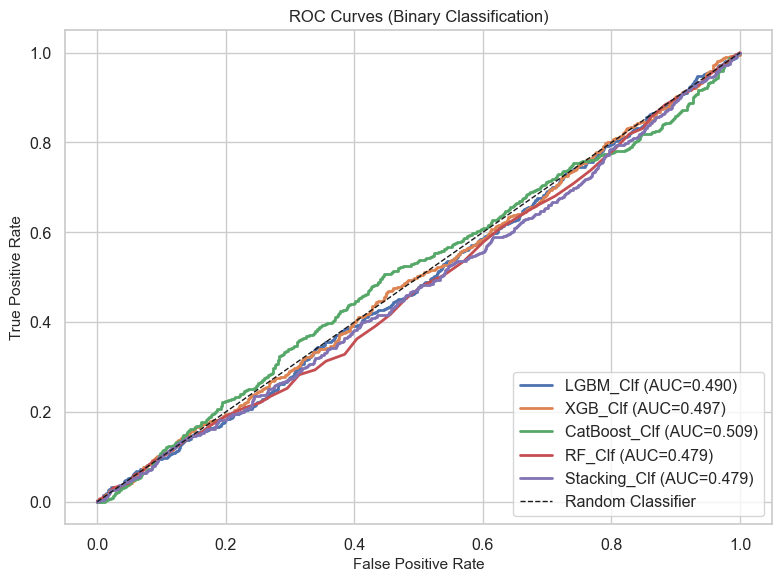

In [9]:
# ============================================================================
# PHASE 7: CLASSIFICATION MODELS (High-Risk Binary Classification)
# ============================================================================
print("\n" + "="*80)
print("PHASE 7: BINARY CLASSIFICATION (Top 15% High-Risk)")
print("="*80)

# Create binary labels (top 15% => high risk)
q = 0.85
threshold = np.quantile(y, q)
y_binary = (y > threshold).astype(int)
print(f"Threshold (top 15%): {threshold:.6f}")
print(f"Positive class (high-risk): {y_binary.mean():.1%}")

# Stratified train/test split
indices = np.arange(len(y))
idx_train_clf, idx_test_clf = train_test_split(
    indices, test_size=0.2, random_state=RANDOM_STATE, stratify=y_binary
)

X_train_clf = X_dl[idx_train_clf]
X_test_clf = X_dl[idx_test_clf]
y_train_clf = y_binary[idx_train_clf]
y_test_clf = y_binary[idx_test_clf]

# Prepare DataFrame inputs for CatBoost
X_tree_train_clf = X_tree_df.loc[idx_train_clf].reset_index(drop=True)
X_tree_test_clf = X_tree_df.loc[idx_test_clf].reset_index(drop=True)

os.makedirs(f"{MODEL_DIR}/classifiers", exist_ok=True)

classification_results = []
classification_models = {}

# LightGBM Classifier
print("\n>>> Training LightGBMClassifier...")
start = time.time()
lgb_clf = lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, random_state=RANDOM_STATE)
lgb_clf.fit(X_train_clf, y_train_clf)
elapsed = time.time() - start
y_prob_lgb = lgb_clf.predict_proba(X_test_clf)[:, 1]
y_pred_lgb = lgb_clf.predict(X_test_clf)
metrics_lgb_clf = compute_classification_metrics(y_test_clf, y_prob_lgb, y_pred_lgb)
metrics_lgb_clf.update({"model": "LGBM_Clf", "time_s": elapsed})
classification_results.append(metrics_lgb_clf)
classification_models["LGBM_Clf"] = lgb_clf
joblib.dump(lgb_clf, f"{MODEL_DIR}/classifiers/lgbm_classifier.joblib")
print(f" LGBM: ROC-AUC={metrics_lgb_clf['roc_auc']:.4f}, F1={metrics_lgb_clf['f1']:.4f}")

# XGBoost Classifier
print("\n>>> Training XGBClassifier...")
start = time.time()
xgb_clf = xgb.XGBClassifier(n_estimators=300, use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE)
xgb_clf.fit(X_train_clf, y_train_clf)
elapsed = time.time() - start
y_prob_xgb = xgb_clf.predict_proba(X_test_clf)[:, 1]
y_pred_xgb = xgb_clf.predict(X_test_clf)
metrics_xgb_clf = compute_classification_metrics(y_test_clf, y_prob_xgb, y_pred_xgb)
metrics_xgb_clf.update({"model": "XGB_Clf", "time_s": elapsed})
classification_results.append(metrics_xgb_clf)
classification_models["XGB_Clf"] = xgb_clf
joblib.dump(xgb_clf, f"{MODEL_DIR}/classifiers/xgb_classifier.joblib")
print(f" XGB: ROC-AUC={metrics_xgb_clf['roc_auc']:.4f}, F1={metrics_xgb_clf['f1']:.4f}")

# CatBoost Classifier
print("\n>>> Training CatBoostClassifier...")
start = time.time()
try:
    cat_clf = CatBoostClassifier(iterations=500, learning_rate=0.05, random_seed=RANDOM_STATE, verbose=0)
    cat_clf.fit(X_tree_train_clf, y_train_clf, cat_features=cat_features,
                eval_set=(X_tree_test_clf, y_test_clf), use_best_model=True)
    elapsed = time.time() - start
    y_prob_cat = cat_clf.predict_proba(X_tree_test_clf)[:, 1]
    y_pred_cat = cat_clf.predict(X_tree_test_clf)
    metrics_cat_clf = compute_classification_metrics(y_test_clf, y_prob_cat, y_pred_cat)
    metrics_cat_clf.update({"model": "CatBoost_Clf", "time_s": elapsed})
    classification_results.append(metrics_cat_clf)
    classification_models["CatBoost_Clf"] = cat_clf
    cat_clf.save_model(f"{MODEL_DIR}/classifiers/catboost_classifier.cbm")
    print(f" CatBoost: ROC-AUC={metrics_cat_clf['roc_auc']:.4f}, F1={metrics_cat_clf['f1']:.4f}")
except Exception as e:
    print(f" CatBoost failed: {e}")

# RandomForest Classifier
print("\n>>> Training RandomForestClassifier...")
start = time.time()
rf_clf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf_clf.fit(X_train_clf, y_train_clf)
elapsed = time.time() - start
y_prob_rf = rf_clf.predict_proba(X_test_clf)[:, 1]
y_pred_rf = rf_clf.predict(X_test_clf)
metrics_rf_clf = compute_classification_metrics(y_test_clf, y_prob_rf, y_pred_rf)
metrics_rf_clf.update({"model": "RF_Clf", "time_s": elapsed})
classification_results.append(metrics_rf_clf)
classification_models["RF_Clf"] = rf_clf
joblib.dump(rf_clf, f"{MODEL_DIR}/classifiers/rf_classifier.joblib")
print(f" RF: ROC-AUC={metrics_rf_clf['roc_auc']:.4f}, F1={metrics_rf_clf['f1']:.4f}")

# Stacking Classifier
print("\n>>> Training StackingClassifier...")
start = time.time()
try:
    estimators_clf = [
        ("lgb", lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=RANDOM_STATE)),
        ("xgb", xgb.XGBClassifier(n_estimators=300, use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE)),
        ("rf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE))
    ]
    stack_clf = StackingClassifier(estimators=estimators_clf, final_estimator=LogisticRegression(max_iter=1000), n_jobs=-1)
    stack_clf.fit(X_train_clf, y_train_clf)
    elapsed = time.time() - start
    y_prob_stack = stack_clf.predict_proba(X_test_clf)[:, 1]
    y_pred_stack = stack_clf.predict(X_test_clf)
    metrics_stack_clf = compute_classification_metrics(y_test_clf, y_prob_stack, y_pred_stack)
    metrics_stack_clf.update({"model": "Stacking_Clf", "time_s": elapsed})
    classification_results.append(metrics_stack_clf)
    classification_models["Stacking_Clf"] = stack_clf
    joblib.dump(stack_clf, f"{MODEL_DIR}/classifiers/stacking_classifier.joblib")
    print(f" Stacking: ROC-AUC={metrics_stack_clf['roc_auc']:.4f}, F1={metrics_stack_clf['f1']:.4f}")
except Exception as e:
    print(f" Stacking classifier failed: {e}")

# Save classification results
clf_df = pd.DataFrame(classification_results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
clf_df.to_csv(f"{RESULTS_DIR}/classification_results.csv", index=False)
joblib.dump(classification_models, f"{MODEL_DIR}/classifiers/models_store_clf.joblib")

print("\n" + "="*80)
print("CLASSIFICATION RESULTS SUMMARY (sorted by ROC-AUC)")
print("="*80)
print(clf_df[["model", "accuracy", "roc_auc", "f1", "precision", "recall"]])
# Save the displayed classification summary (subset) to CSV
clf_df[["model", "accuracy", "roc_auc", "f1", "precision", "recall"]].to_csv(f"{RESULTS_DIR}/classification_summary.csv", index=False)
print(f"Saved classification summary to: {RESULTS_DIR}/classification_summary.csv")

# Plot classification results
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.barplot(x="model", y="accuracy", data=clf_df, palette="mako", ax=axes[0, 0])
axes[0, 0].set_title("Accuracy")
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=45, ha='right')

sns.barplot(x="model", y="roc_auc", data=clf_df, palette="viridis", ax=axes[0, 1])
axes[0, 1].set_title("ROC-AUC (higher better)")
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45, ha='right')

sns.barplot(x="model", y="f1", data=clf_df, palette="coolwarm", ax=axes[0, 2])
axes[0, 2].set_title("F1-Score")
axes[0, 2].set_xticklabels(axes[0, 2].get_xticklabels(), rotation=45, ha='right')

sns.barplot(x="model", y="precision", data=clf_df, palette="Set2", ax=axes[1, 0])
axes[1, 0].set_title("Precision")
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=45, ha='right')

sns.barplot(x="model", y="recall", data=clf_df, palette="husl", ax=axes[1, 1])
axes[1, 1].set_title("Recall (Sensitivity)")
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right')

axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

# ROC curves
plt.figure(figsize=(8, 6))
plotted = 0
for name, mdl in classification_models.items():
    try:
        if name == "CatBoost_Clf":
            probs = mdl.predict_proba(X_tree_test_clf)[:, 1]
        else:
            probs = mdl.predict_proba(X_test_clf)[:, 1]
        fpr, tpr, _ = roc_curve(y_test_clf, probs)
        auc_score = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc_score:.3f})", linewidth=2)
        plotted += 1
    except:
        continue

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label="Random Classifier")
plt.xlabel("False Positive Rate", fontsize=11)

plt.ylabel("True Positive Rate", fontsize=11)
plt.title("ROC Curves (Binary Classification)", fontsize=12)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [10]:
# ============================================================================
# PHASE 8: FINAL RESULTS AGGREGATION & SUMMARY
# ============================================================================
print("\n" + "="*80)
print("FINAL RESULTS & MODEL COMPARISON")
print("="*80)

# Aggregate all regression results
all_reg_df = pd.DataFrame(regression_results).sort_values("MAE").reset_index(drop=True)
all_reg_df.to_csv(f"{RESULTS_DIR}/all_regression_results.csv", index=False)

print("\n" + "="*80)
print("ALL REGRESSION MODELS (sorted by MAE):")
print("="*80)
print(all_reg_df[["model", "MAE", "RMSE", "R2", "time_s"]].to_string(index=False))

# Summary statistics
print("\nRegression Metrics Summary Statistics:")
stats_df = all_reg_df[["MAE", "RMSE", "R2", "time_s"]].describe()
print(stats_df.to_string())

# Best models per metric
print("\nBest Models per Metric:")
best_metrics = pd.DataFrame({
    "Metric": ["Best MAE", "Best RMSE", "Best R2", "Fastest"],
    "Model": [
        all_reg_df.loc[all_reg_df["MAE"].idxmin(), "model"],
        all_reg_df.loc[all_reg_df["RMSE"].idxmin(), "model"],
        all_reg_df.loc[all_reg_df["R2"].idxmax(), "model"],
        all_reg_df.loc[all_reg_df["time_s"].idxmin(), "model"]
    ],
    "Value": [
        f"{all_reg_df['MAE'].min():.4f}",
        f"{all_reg_df['RMSE'].min():.4f}",
        f"{all_reg_df['R2'].max():.4f}",
        f"{all_reg_df['time_s'].min():.2f}s"
    ]
})
print(best_metrics.to_string(index=False))

# Save all models
for k, m in regression_models.items():
    try:
        if isinstance(m, tuple):
            autoencoder, encoder, reg = m
            autoencoder.save(f"{MODEL_DIR}/model_{k}_autoencoder")
            joblib.dump(reg, f"{MODEL_DIR}/model_{k}_lgb.joblib")
        elif hasattr(m, "save"):
            m.save(f"{MODEL_DIR}/model_{k}")
        else:
            joblib.dump(m, f"{MODEL_DIR}/model_{k}.joblib")
        print(f"✓ Saved regression model: {k}")
    except Exception as e:
        print(f"✗ Failed to save {k}: {e}")

print("\n" + "="*80)
print("EXPERIMENT COMPLETED")
print("="*80)
print(f"Results saved to: {RESULTS_DIR}/")
print(f"Models saved to: {MODEL_DIR}/")
print(f"\nKey outputs:")
print(f"  - {RESULTS_DIR}/all_regression_results.csv")
print(f"  - {RESULTS_DIR}/classification_results.csv")
print(f"  - {MODEL_DIR}/ (all trained models)")


FINAL RESULTS & MODEL COMPARISON

ALL REGRESSION MODELS (sorted by MAE):
               model   MAE  RMSE     R2  time_s
            LightGBM 4.090 5.076  0.001   2.210
Autoencoder+LightGBM 4.091 5.078 -0.000   0.096
            CatBoost 4.092 5.078 -0.000  45.331
  Stacking_Regressor 4.094 5.081 -0.001  85.109
        RandomForest 4.112 5.096 -0.007  12.872
      WideDeep_Keras 4.172 5.172 -0.038   0.000
             XGBoost 4.190 5.215 -0.055   1.005

Regression Metrics Summary Statistics:
        MAE  RMSE     R2  time_s
count 7.000 7.000  7.000   7.000
mean  4.120 5.114 -0.014  20.946
std   0.043 0.056  0.022  32.657
min   4.090 5.076 -0.055   0.000
25%   4.092 5.078 -0.023   0.551
50%   4.094 5.081 -0.001   2.210
75%   4.142 5.134 -0.000  29.101
max   4.190 5.215  0.001  85.109

Best Models per Metric:
   Metric          Model  Value
 Best MAE       LightGBM 4.0902
Best RMSE       LightGBM 5.0757
  Best R2       LightGBM 0.0006
  Fastest WideDeep_Keras  0.00s
✓ Saved regression m

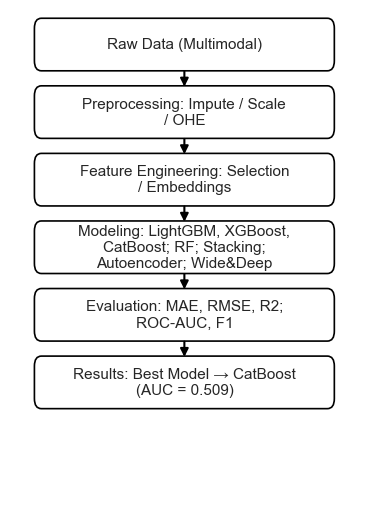

In [11]:
# ============================================================================
# FIG. 1: End-to-End Injury Risk Prediction Pipeline (vertical layout)
# ============================================================================

import os
import textwrap
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

plt.rcParams.update({'font.size': 10, 'font.family': 'sans-serif'})

# Reduced height to remove bottom whitespace
fig, ax = plt.subplots(figsize=(4.5, 6.5))
ax.axis('off')

def draw_box_frac(xc, yc, w, h, label, fontsize=11):
    x = xc - w / 2
    y = yc - h / 2

    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        transform=ax.transAxes,
        boxstyle='round,pad=0.02',
        linewidth=1.2,
        facecolor='white',
        edgecolor='black'
    )
    ax.add_patch(box)

    wrapped = '\n'.join(textwrap.wrap(label, width=30))
    ax.text(xc, yc, wrapped, transform=ax.transAxes,
            ha='center', va='center', fontsize=fontsize)

# ---------------------------------------------------------------------------
# Layout (tightened)
# ---------------------------------------------------------------------------
labels = [
    'Raw Data (Multimodal)',
    'Preprocessing: Impute / Scale / OHE',
    'Feature Engineering: Selection / Embeddings',
    'Modeling: LightGBM, XGBoost, CatBoost; RF; Stacking; Autoencoder; Wide&Deep',
    'Evaluation: MAE, RMSE, R2; ROC-AUC, F1',
    'Results: Best Model → CatBoost (AUC = 0.509)'
]

box_h = 0.065
box_w = 0.82
top = 0.93
gap = 0.07

centers = [top - i * (box_h + gap) for i in range(len(labels))]

# ---------------------------------------------------------------------------
# Draw boxes
# ---------------------------------------------------------------------------
for yc, lab in zip(centers, labels):
    draw_box_frac(0.5, yc, box_w, box_h, lab)

# ---------------------------------------------------------------------------
# Arrows: BORDER-TO-BORDER (no floating)
# ---------------------------------------------------------------------------

border_pad = 0.01
for i in range(len(centers) - 1):
    start_y = centers[i] - box_h / 2 - border_pad
    end_y   = centers[i + 1] + box_h / 2 + border_pad

    ax.annotate(
        '',
        xy=(0.5, end_y),
        xytext=(0.5, start_y),
        xycoords='axes fraction',
        textcoords='axes fraction',
        arrowprops=dict(
            arrowstyle='-|>',
            lw=1.5,
            mutation_scale=12,
            shrinkA=4,
            shrinkB=3,
            color='black'
        )
    )

# ---------------------------------------------------------------------------
# Save outputs (no extra whitespace)
# ---------------------------------------------------------------------------
out_dir = RESULTS_DIR if 'RESULTS_DIR' in globals() else 'results'
os.makedirs(out_dir, exist_ok=True)

plt.savefig(f"{out_dir}/fig1_pipeline_vertical.png",
            dpi=1200, bbox_inches='tight', pad_inches=0.02)

plt.show()